In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# New Yorker Caption Contest - Image Captioning with ViT-GPT2
# Full Google Colab Notebook: Training + ONNX Export + TensorRT Inference

# =============================
# STEP 1: Install dependencies
# =============================
!pip install -q datasets transformers torchvision accelerate
!pip install -q onnx onnxruntime
!pip install -q tensorrt --extra-index-url https://pypi.ngc.nvidia.com
!pip install -q pycuda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/40.2k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00000-of-00001.parquet:   0%|          | 0.00/90.7M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

test-00000-of-00001.parquet:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1596 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/506 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/513 [00:00<?, ? examples/s]

{'image': <PIL.Image.Image image mode=L size=600x471 at 0x7D714944E9D0>, 'contest_number': 556, 'caption_choices': ['Another executive order?', 'We had meth on Tuesday.'], 'winner_source': 'official_winner', 'label': 'B', 'n_tokens_label': 1, 'instance_id': '078e0d07dc22459f6cca41dd49761091'}


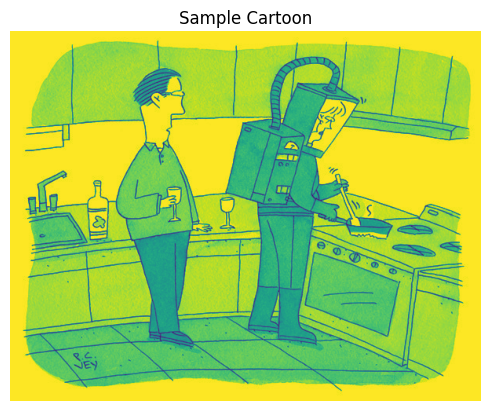

Captions: ['Another executive order?', 'We had meth on Tuesday.']


In [5]:
# =============================
# STEP 2: Load and Explore Dataset
# =============================
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('jmhessel/newyorker_caption_contest',
                       name='ranking_from_pixels', split="train")

# Preview a cartoon
sample = dataset[0]
print(sample)
plt.imshow(sample['image'])
plt.axis('off')
plt.title("Sample Cartoon")
plt.show()
print("Captions:", sample['caption_choices'])

In [6]:
# =============================
# STEP 3: Preprocessing
# =============================
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import torch
from datasets import Features, Value, Sequence, Array3D
import numpy as np

model_name = "nlpconnect/vit-gpt2-image-captioning"
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = VisionEncoderDecoderModel.from_pretrained(model_name)

transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize([0.5], [0.5])
])

# Define expected data types for features
# Use Array3D to represent pixel_values as a 3D array
features = Features({
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),  # 3D array for pixel_values
    'labels': Sequence(Value('int64')),  # Sequence for labels (token IDs)
})

def preprocess(example):
    image = example['image'].convert("RGB")
    caption = example['caption_choices'][0]

    # Ensure image tensor is shape (3, 224, 224) and convert to tensor
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    # Convert to a regular PyTorch tensor (not a Hugging Face Tensor)
    pixel_values = pixel_values.squeeze(0).type(torch.FloatTensor)
    # Convert to NumPy array
    pixel_values = pixel_values.numpy() # Convert to NumPy array

    # Tokenize caption and convert to tensor
    labels = tokenizer(caption, padding="max_length", truncation=True, max_length=128, return_tensors="pt").input_ids.squeeze(0)
    # Convert to a regular PyTorch tensor (not a Hugging Face Tensor)
    labels = labels.type(torch.LongTensor)
     # Convert to a list of integers (for 'labels' feature)
    labels = labels.tolist() # Convert to a list


    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

# Apply preprocessing with type specification
processed_dataset = dataset.map(preprocess,
                                remove_columns=dataset.column_names,
                                features=features)

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

Map:   0%|          | 0/1596 [00:00<?, ? examples/s]

In [7]:
# =============================
# STEP 4: Training
# =============================
from torch.utils.data import DataLoader

def collate_fn(batch):
    # Stack pixel_values as before
    pixel_values = torch.stack([torch.tensor(item['pixel_values']) for item in batch])

    # Convert labels to tensors before stacking
    labels = [torch.tensor(item['labels']) for item in batch]  # Convert each item to tensor
    labels = torch.stack(labels)  # Stack the tensors

    return {"pixel_values": pixel_values, "labels": labels}

train_loader = DataLoader(processed_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device using: ", device)
model.to(device)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
from tqdm import tqdm

train_losses = []
for epoch in range(3):
    epoch_loss = 0
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    # Average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")


Device using:  cuda


  0%|          | 0/200 [00:00<?, ?it/s]We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
Epoch 0: 100%|██████████| 200/200 [03:09<00:00,  1.06it/s, loss=0.722]


Epoch 0 - Average Loss: 0.6446


Epoch 1: 100%|██████████| 200/200 [03:01<00:00,  1.10it/s, loss=0.504]


Epoch 1 - Average Loss: 0.5319


Epoch 2: 100%|██████████| 200/200 [03:02<00:00,  1.10it/s, loss=0.54]

Epoch 2 - Average Loss: 0.4921


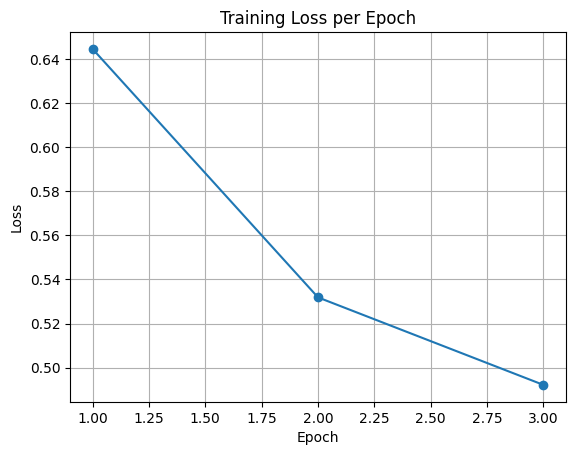

In [8]:
# ======================================
# STEP 5: Visualise the training loss
# ======================================
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [15]:
# =============================
# STEP 6: Save ONNX Encoder
# =============================
# model.eval()
# encoder = model.get_encoder()

# dummy_image = torch.randn(1, 3, 224, 224).to(device)
# torch.onnx.export(
#     encoder,
#     dummy_image,
#     "image_captioning_vit_encoder.onnx",
#     input_names=["pixel_values"],
#     output_names=["encoder_hidden_states"],
#     opset_version=14
# )
# print("ONNX model saved as image_captioning_vit_encoder.onnx")

# =============================
# STEP 7: Convert to TensorRT
# =============================
import tensorrt as trt
TRT_LOGGER = trt.Logger()

builder = trt.Builder(TRT_LOGGER)
network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
parser = trt.OnnxParser(network, TRT_LOGGER)

with open("image_captioning_vit_encoder.onnx", "rb") as f:
    if not parser.parse(f.read()):
        for i in range(parser.num_errors):
            print(parser.get_error(i))

# Create a config object
config = builder.create_builder_config()
# Set max_workspace_size through the config object using set_memory_pool_limit
config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)
config.set_flag(trt.BuilderFlag.FP16) # Use config.set_flag to enable FP16
# Build the engine using the config
# In newer TensorRT versions, use build_serialized_network instead
serialized_engine = builder.build_serialized_network(network, config)  # Get serialized engine



with open("image_captioning_vit_encoder.trt", "wb") as f:
    f.write(serialized_engine)
print("TensorRT engine saved as image_captioning_vit_encoder.trt")

TensorRT engine saved as image_captioning_vit_encoder.trt
